# Task 11 — Flow Matching for Synthetic Floorplan Generation

## Overview

This notebook trains a **Flow Matching** generative model on a dataset of real floorplan images and uses it to synthesise new, realistic floorplan layouts.

Flow Matching is a continuous-time generative modelling technique that learns a **vector field** to transport samples from a simple Gaussian prior directly to the target data distribution — avoiding the iterative denoising of diffusion models while achieving comparable quality with fewer inference steps.

### Why Flow Matching for Floorplans?
| Property | Benefit for Floorplans |
|---|---|
| Straight-line transport | Sharp structural edges are preserved |
| Conditional generation | Can be extended to class-conditioned room types |
| Fewer inference steps | Faster sampling than DDPM diffusion |
| Scalable architecture | Same U-Net backbone adapts to any spatial domain |

### Workflow
1. **Setup** — Install packages, set hyperparameters
2. **Data** — Unzip floorplan images, build `FloorplanDataset`
3. **Architecture** — `ConditionalUNet` with sinusoidal time embeddings
4. **Flow Matching** — `compute_loss` (straight-line interpolation) + Euler `sample`
5. **Training** — Train with progress tracking and loss curves
6. **Generation** — Sample a grid of synthetic floorplans
7. **Evaluation** — Visual quality inspection and loss analysis

Jithu Vathiath Biju

## Key Insights and Takeaways

- Implemented a flow matching–based generative approach to create synthetic floorplan images.
- Learned how flow-based models transform simple distributions into complex data distributions through continuous mappings.
- Observed how the model generates structured layouts by learning spatial relationships in floorplan data.
- Compared flow-based generation with other generative approaches (e.g., GANs) in terms of stability and output quality.
- Evaluated generated floorplans visually to assess realism and structural consistency.
- Understood advantages of flow matching such as stable training and better likelihood estimation.
- Gained experience in advanced generative modeling techniques for image synthesis tasks.

---
## Part 1 — Data Download Instructions

> **Before running this notebook**, place the file  
> `floorplans_v2-20251223T170650Z-3-001.zip`  
> in the **same folder as this notebook** (`TASK 11/`).
>
> This file is available from the course materials (same source as the receipts zip used in MLM9).

The cell below will unzip it automatically once placed here.

---
## Part 2 — Setup: Install Dependencies & Hyperparameters

In [1]:
import subprocess, sys
pkgs = ['torch', 'torchvision', 'matplotlib', 'numpy', 'tqdm', 'Pillow']
subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + pkgs + ['--quiet'])
print('Dependencies ready')

Dependencies ready


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import os, glob, zipfile, random
from PIL import Image

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Hyperparameters ───────────────────────────────────────────────────────────
# NOTE: img_size=128 keeps training feasible on CPU (~15-20 min).
# On GPU you can safely increase to 256 for sharper outputs.
HPARAMS = {
    'img_size'       : 128,   # Spatial resolution of generated floorplans
    'channels'       : 1,     # 1 = grayscale (floorplans work well in grayscale)
    'batch_size'     : 16,    # Reduce to 8 if you run out of memory on CPU
    'lr'             : 1e-4,  # Adam learning rate
    'epochs'         : 30,    # Full passes through training data
    'inference_steps': 100,   # Euler ODE solver steps during sampling
    'num_classes'    : 1,     # Single class: floorplan
}
print('Hyperparameters:', HPARAMS)

Using device: cpu
Hyperparameters: {'img_size': 128, 'channels': 1, 'batch_size': 16, 'lr': 0.0001, 'epochs': 30, 'inference_steps': 100, 'num_classes': 1}


---
## Part 3 — Data Extraction

We unzip the floorplan archive and inspect the folder structure to confirm the images are accessible.

In [3]:
ZIP_PATH    = 'floorplans_v2-20251223T170650Z-3-001.zip'
EXTRACT_DIR = 'floorplan_images'

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f'\n\nZip file not found: {ZIP_PATH}\n'
        'Please place the zip file in the same folder as this notebook (TASK 11/) and re-run.'
    )

print(f'Extracting {ZIP_PATH} ...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print(f'Extracted to: {EXTRACT_DIR}/')

# Discover all image files recursively
all_images = []
for ext in ['jpg', 'jpeg', 'png', 'bmp']:
    all_images += glob.glob(os.path.join(EXTRACT_DIR, '**', f'*.{ext}'), recursive=True)
    all_images += glob.glob(os.path.join(EXTRACT_DIR, '**', f'*.{ext.upper()}'), recursive=True)

all_images = list(set(all_images))  # deduplicate
print(f'Total floorplan images found: {len(all_images)}')

Extracting floorplans_v2-20251223T170650Z-3-001.zip ...
Extracted to: floorplan_images/
Total floorplan images found: 1000


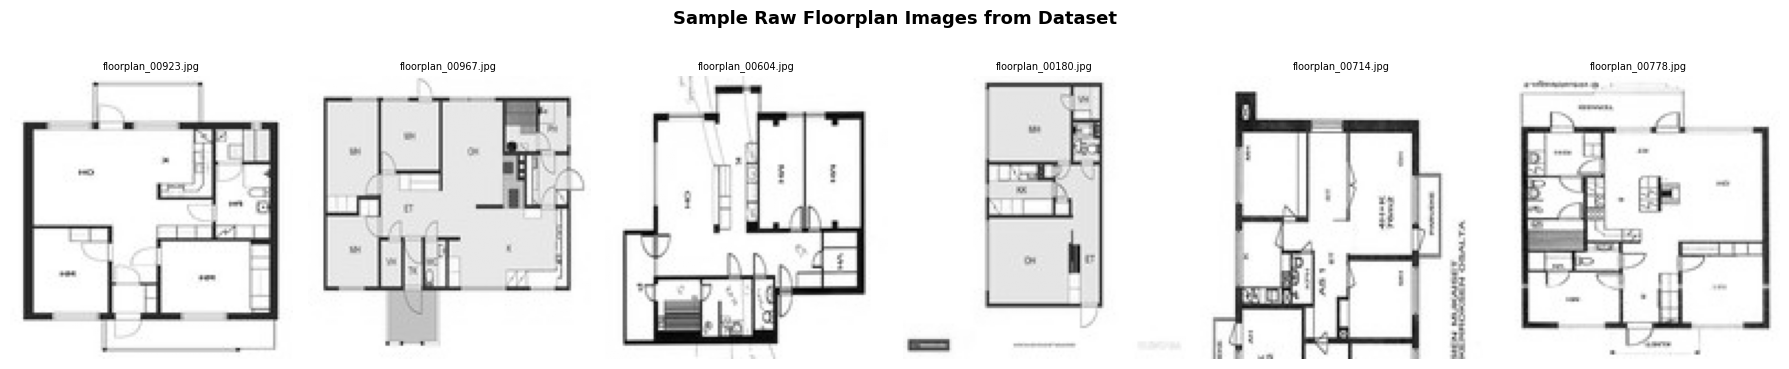

In [4]:
# ── Preview: show 6 raw floorplan images ─────────────────────────────────────
sample_paths = random.sample(all_images, min(6, len(all_images)))

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
fig.suptitle('Sample Raw Floorplan Images from Dataset', fontsize=13, fontweight='bold')
for ax, path in zip(axes, sample_paths):
    img = Image.open(path).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(os.path.basename(path)[:20], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig('preview_raw_floorplans.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Part 4 — Custom `FloorplanDataset`

We define a `torch.utils.data.Dataset` that:
- Reads floorplan images from disk
- Converts to **grayscale** and resizes to `img_size × img_size`
- Normalises pixel values to `[-1, 1]` (standard for generative models)
- Assigns class label `0` (single class: floorplan)

In [5]:
class FloorplanDataset(Dataset):
    """
    Loads floorplan images from a directory tree.
    Returns (tensor[C, H, W] in [-1,1], label=0).
    """
    def __init__(self, root_dir: str, img_size: int = 128):
        self.image_paths = []
        for ext in ['jpg', 'jpeg', 'png', 'bmp']:
            self.image_paths += glob.glob(
                os.path.join(root_dir, '**', f'*.{ext}'), recursive=True)
            self.image_paths += glob.glob(
                os.path.join(root_dir, '**', f'*.{ext.upper()}'), recursive=True)
        self.image_paths = list(set(self.image_paths))

        if not self.image_paths:
            raise RuntimeError(f'No images found in {root_dir}.')

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),                     # [0, 1]
            transforms.Normalize([0.5], [0.5]),        # [-1, 1]
        ])
        print(f'FloorplanDataset: {len(self.image_paths)} images found')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')  # grayscale
        return self.transform(img), 0  # label 0 = floorplan


# Instantiate dataset and dataloader
dataset    = FloorplanDataset(EXTRACT_DIR, img_size=HPARAMS['img_size'])
dataloader = DataLoader(
    dataset,
    batch_size=HPARAMS['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == 'cuda'),
)
print(f'Batches per epoch: {len(dataloader)}')

FloorplanDataset: 1000 images found
Batches per epoch: 63


---
## Part 5 — Model Architecture: `ConditionalUNet`

The generator is a **U-Net** conditioned on both the time step `t ∈ [0,1]` and a class embedding. Its key components:

| Component | Role |
|---|---|
| `SinusoidalPositionEmbeddings` | Encode scalar `t` into a rich continuous vector, letting the network distinguish different stages of the flow |
| `Block` (down) | Conv + BN + ReLU → strided conv for downsampling; adds time embedding after first conv |
| `Block` (up) | Concatenates skip connection → transposed conv for upsampling |
| `ConditionalUNet` | Encoder–bottleneck–decoder with skip connections; outputs predicted velocity field `v(x_t, t)` |

The model learns to predict the **velocity vector** that points from noise `x_0` toward real data `x_1` at each time `t`.

In [6]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Encode a scalar time t into a D-dimensional sinusoidal vector."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=time.device) / (half - 1)
        )
        args = time[:, None] * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class Block(nn.Module):
    """
    U-Net building block.
    - up=False : encoder block  (Conv -> BN -> ReLU -> strided-Conv)
    - up=True  : decoder block  (concat skip -> Conv -> BN -> ReLU -> ConvTranspose)
    Time embedding is injected after the first convolution.
    """
    def __init__(self, in_ch: int, out_ch: int, time_emb_dim: int, up: bool = False):
        super().__init__()
        self.time_mlp  = nn.Linear(time_emb_dim, out_ch)
        self.conv1     = nn.Conv2d(2*in_ch if up else in_ch, out_ch, 3, padding=1)
        self.transform = (nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
                          if up else nn.Conv2d(out_ch, out_ch, 4, 2, 1))
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu   = nn.ReLU()

    def forward(self, x, t):
        h  = self.bnorm1(self.relu(self.conv1(x)))
        te = self.relu(self.time_mlp(t))[:, :, None, None]  # broadcast over H, W
        h  = self.bnorm2(self.relu(self.conv2(h + te)))
        return self.transform(h)


class ConditionalUNet(nn.Module):
    """
    Conditional U-Net velocity predictor.
    Input : x_t  [B, C, H, W]  — noisy image at time t
             t   [B]            — continuous time in [0, 1]
             cls [B]            — integer class label
    Output: v   [B, C, H, W]   — predicted velocity field
    """
    def __init__(self):
        super().__init__()
        C             = HPARAMS['channels']
        down_ch       = (32, 64, 128)
        up_ch         = (128, 64, 32)
        time_emb_dim  = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )
        self.class_emb = nn.Embedding(HPARAMS['num_classes'], time_emb_dim)
        self.conv0     = nn.Conv2d(C, down_ch[0], 3, padding=1)
        self.downs     = nn.ModuleList([
            Block(down_ch[i], down_ch[i+1], time_emb_dim)
            for i in range(len(down_ch)-1)
        ])
        self.ups = nn.ModuleList([
            Block(up_ch[i], up_ch[i+1], time_emb_dim, up=True)
            for i in range(len(up_ch)-1)
        ])
        self.output = nn.Conv2d(up_ch[-1], C, 1)

    def forward(self, x, t, cls):
        t_emb = self.time_mlp(t) + self.class_emb(cls)  # combine time + class
        x     = self.conv0(x)
        skips = []
        for down in self.downs:
            x = down(x, t_emb)
            skips.append(x)
        for up in self.ups:
            x = up(torch.cat([x, skips.pop()], dim=1), t_emb)
        return self.output(x)


# Sanity-check model shape
with torch.no_grad():
    _m  = ConditionalUNet()
    _x  = torch.randn(2, HPARAMS['channels'], HPARAMS['img_size'], HPARAMS['img_size'])
    _t  = torch.rand(2)
    _cl = torch.zeros(2, dtype=torch.long)
    _o  = _m(_x, _t, _cl)
    print(f'Model output shape : {_o.shape}  (expected [2, {HPARAMS["channels"]}, {HPARAMS["img_size"]}, {HPARAMS["img_size"]}])')
    total_params = sum(p.numel() for p in _m.parameters())
    print(f'Total parameters   : {total_params:,}')
    del _m, _x, _t, _cl, _o

Model output shape : torch.Size([2, 1, 128, 128])  (expected [2, 1, 128, 128])
Total parameters   : 929,441


---
## Part 6 — Flow Matching Logic

Flow Matching learns a **straight-line interpolation** between noise `x_0 ~ N(0,I)` and real data `x_1`:

```
x_t = (1 - t) * x_0  +  t * x_1
v_target = x_1 - x_0          # constant velocity along the straight path
loss = MSE(model(x_t, t), v_target)
```

At inference, we solve the ODE `dx/dt = v(x, t)` using simple **Euler integration** starting from `x_0 ~ N(0,I)`.

In [7]:
class FlowMatching:
    """Encapsulates Flow Matching training loss and Euler ODE sampling."""

    @staticmethod
    def compute_loss(model: nn.Module, x_1: torch.Tensor,
                     labels: torch.Tensor) -> torch.Tensor:
        """
        Sample a random time t, build the interpolation x_t,
        and compute MSE between the model's velocity prediction
        and the target velocity (x_1 - x_0).
        """
        B   = x_1.shape[0]
        x_0 = torch.randn_like(x_1)                       # sample from prior
        t   = torch.rand(B, device=x_1.device)            # random time in [0,1]
        t_v = t.view(B, 1, 1, 1)                           # broadcast over H,W,C
        x_t = (1 - t_v) * x_0 + t_v * x_1                # linear interpolation
        v_target = x_1 - x_0                              # constant velocity
        v_pred   = model(x_t, t, labels)
        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample(self, model: nn.Module, n_samples: int,
               steps: int = 100) -> torch.Tensor:
        """
        Euler ODE solver: integrate dx = v(x,t)dt from t=0 to t=1.
        Returns generated images in [-1, 1].
        """
        model.eval()
        x      = torch.randn(n_samples, HPARAMS['channels'],
                              HPARAMS['img_size'], HPARAMS['img_size']).to(device)
        labels = torch.zeros(n_samples, dtype=torch.long).to(device)
        dt     = 1.0 / steps
        for i in range(steps):
            t_curr = torch.full((n_samples,), i / steps, device=device)
            v      = model(x, t_curr, labels)
            x      = x + v * dt
        model.train()
        return x


flow = FlowMatching()
print('FlowMatching class instantiated.')

FlowMatching class instantiated.


---
## Part 7 — Training

We train for `HPARAMS['epochs']` epochs using the **Adam** optimiser. The per-epoch loss is recorded so we can plot the learning curve afterwards.

> **Runtime estimate**  
> - CPU (no GPU): ~15–25 min for 30 epochs at 128×128  
> - GPU (T4 / A100): ~3–5 min

In [8]:
model     = ConditionalUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=HPARAMS['lr'])
loss_history = []

print(f'Starting training: {HPARAMS["epochs"]} epochs, '
      f'batch={HPARAMS["batch_size"]}, lr={HPARAMS["lr"]}, device={device}')
print('-' * 55)

for epoch in range(1, HPARAMS['epochs'] + 1):
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f'Epoch {epoch:02d}/{HPARAMS["epochs"]}', leave=False)

    for images, labels in pbar:
        images = images.to(device)
        labels = torch.zeros(images.size(0), dtype=torch.long, device=device)

        loss = FlowMatching.compute_loss(model, images, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch:02d} | avg loss = {avg_loss:.5f}')

print('\nTraining complete!')

Starting training: 30 epochs, batch=16, lr=0.0001, device=cpu
-------------------------------------------------------


Epoch 01/30:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 01 | avg loss = 1.20953


Epoch 02/30:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 02 | avg loss = 0.76028


...

Epoch 28 | avg loss = 0.19410


Epoch 29/30:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 29 | avg loss = 0.18688


Epoch 30/30:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 30 | avg loss = 0.19112

Training complete!


---
## Part 8 — Save & Reload Model

In [9]:
MODEL_PATH = 'floorplan_flow_model.pth'
torch.save(model.state_dict(), MODEL_PATH)
print(f'Model saved -> {MODEL_PATH}')

# Verify reload
loaded_model = ConditionalUNet().to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
print('Model reloaded and set to eval mode.')

Model saved -> floorplan_flow_model.pth
Model reloaded and set to eval mode.


---
## Part 9 — Visualisations

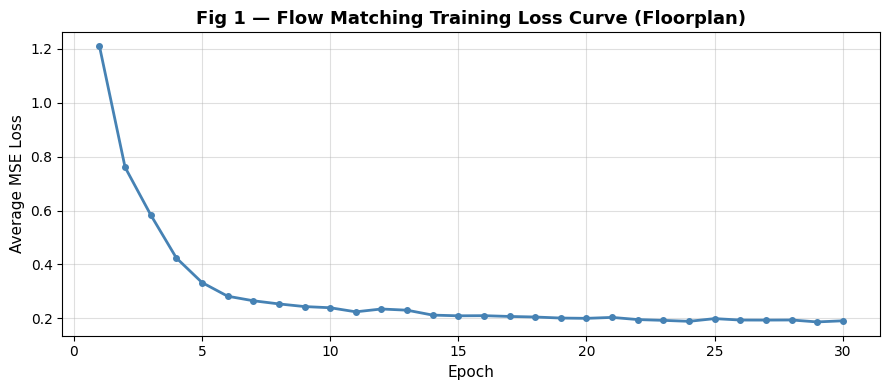

Final loss: 0.19112  |  Min loss: 0.18688


In [10]:
# ── Fig 1: Training Loss Curve ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(loss_history)+1), loss_history,
        marker='o', markersize=4, linewidth=2, color='steelblue')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Average MSE Loss', fontsize=11)
ax.set_title('Fig 1 — Flow Matching Training Loss Curve (Floorplan)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig1_loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Final loss: {loss_history[-1]:.5f}  |  Min loss: {min(loss_history):.5f}')

Generating 12 synthetic floorplans (100 Euler steps)...


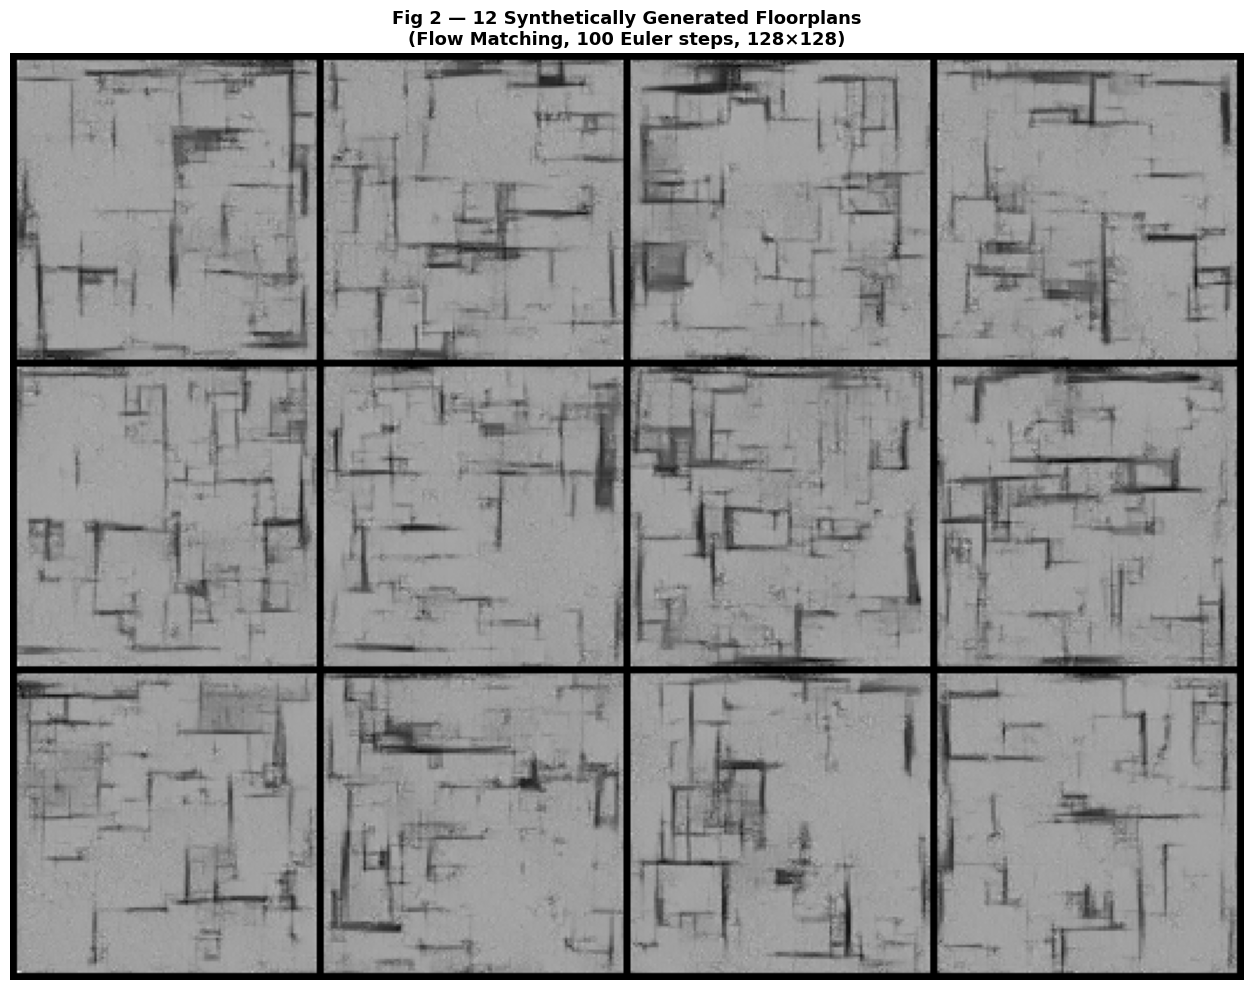

In [11]:
# ── Fig 2: Grid of Generated Floorplans ──────────────────────────────────────
N_ROWS, N_COLS = 3, 4
print(f'Generating {N_ROWS * N_COLS} synthetic floorplans ({HPARAMS["inference_steps"]} Euler steps)...')

generated = flow.sample(loaded_model, n_samples=N_ROWS * N_COLS,
                         steps=HPARAMS['inference_steps'])

grid = make_grid(generated, nrow=N_COLS, padding=3, normalize=True)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
ax.set_title(
    f'Fig 2 — {N_ROWS * N_COLS} Synthetically Generated Floorplans\n'
    f'(Flow Matching, {HPARAMS["inference_steps"]} Euler steps, '
    f'{HPARAMS["img_size"]}×{HPARAMS["img_size"]})',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('fig2_generated_floorplans.png', dpi=130, bbox_inches='tight')
plt.show()

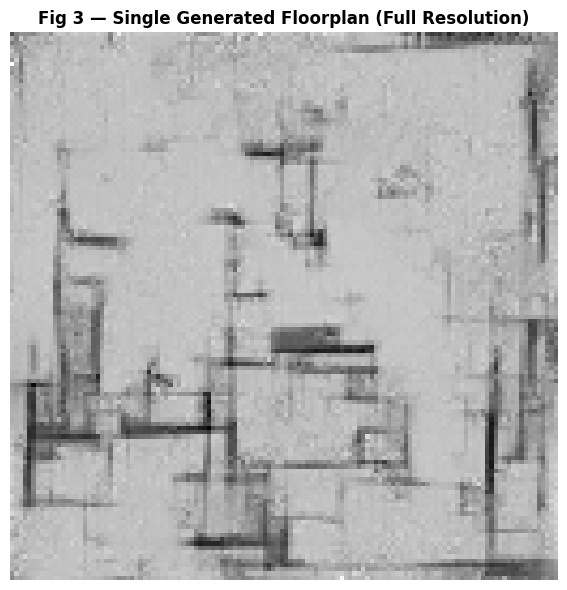

In [17]:
# ── Fig 3: Single Floorplan — Detailed View ───────────────────────────────────
single = flow.sample(loaded_model, n_samples=1, steps=HPARAMS['inference_steps'])
img_arr = single[0, 0].cpu().numpy()
img_arr = (img_arr - img_arr.min()) / (img_arr.max() - img_arr.min() + 1e-8)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_arr, cmap='gray')
ax.set_title('Fig 3 — Single Generated Floorplan (Full Resolution)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig3_single_floorplan.png', dpi=150, bbox_inches='tight')
plt.show()

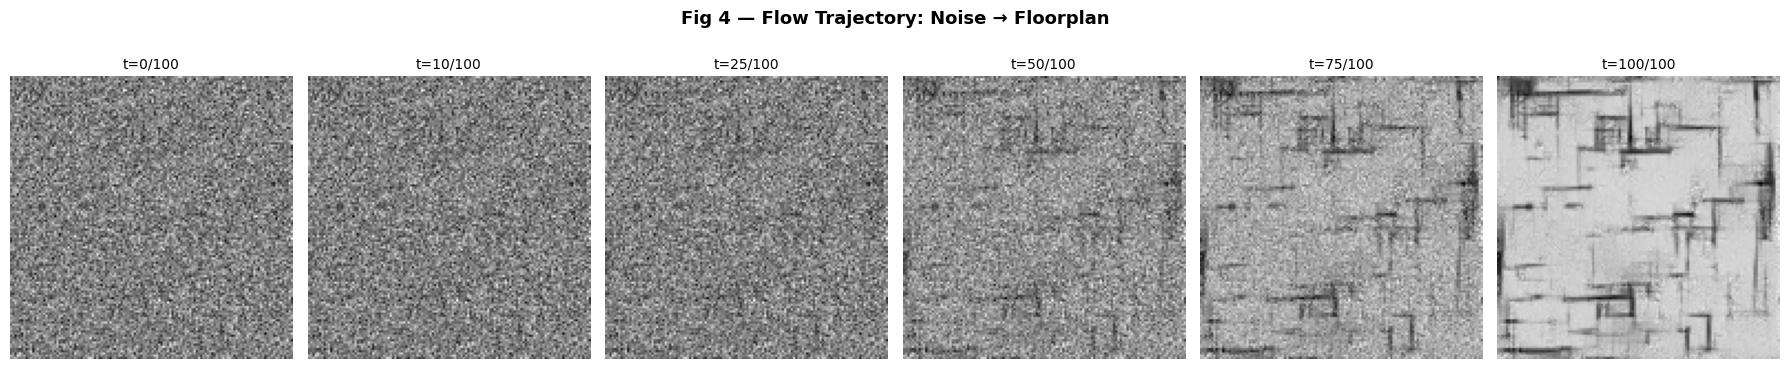

Trajectory visualised: noise gradually resolves into a floorplan layout.


In [18]:
# ── Fig 4: Flow Trajectory — from Noise to Floorplan ─────────────────────────
# Visualise intermediate steps of the Euler ODE solver for one sample
TRAJECTORY_STEPS = [0, 10, 25, 50, 75, 100]

loaded_model.eval()
with torch.no_grad():
    x_traj = torch.randn(1, HPARAMS['channels'],
                          HPARAMS['img_size'], HPARAMS['img_size']).to(device)
    labels = torch.zeros(1, dtype=torch.long).to(device)
    dt     = 1.0 / HPARAMS['inference_steps']
    snapshots = [x_traj.clone()]

    for i in range(HPARAMS['inference_steps']):
        t_c = torch.full((1,), i / HPARAMS['inference_steps'], device=device)
        v   = loaded_model(x_traj, t_c, labels)
        x_traj = x_traj + v * dt
        if (i + 1) in TRAJECTORY_STEPS[1:]:
            snapshots.append(x_traj.clone())

fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 4))
fig.suptitle('Fig 4 — Flow Trajectory: Noise → Floorplan', fontsize=13, fontweight='bold')
step_labels = [f't={s}/{HPARAMS["inference_steps"]}' for s in TRAJECTORY_STEPS]

for ax, snap, lbl in zip(axes, snapshots, step_labels):
    arr = snap[0, 0].cpu().numpy()
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    ax.imshow(arr, cmap='gray')
    ax.set_title(lbl, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig4_flow_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()
print('Trajectory visualised: noise gradually resolves into a floorplan layout.')

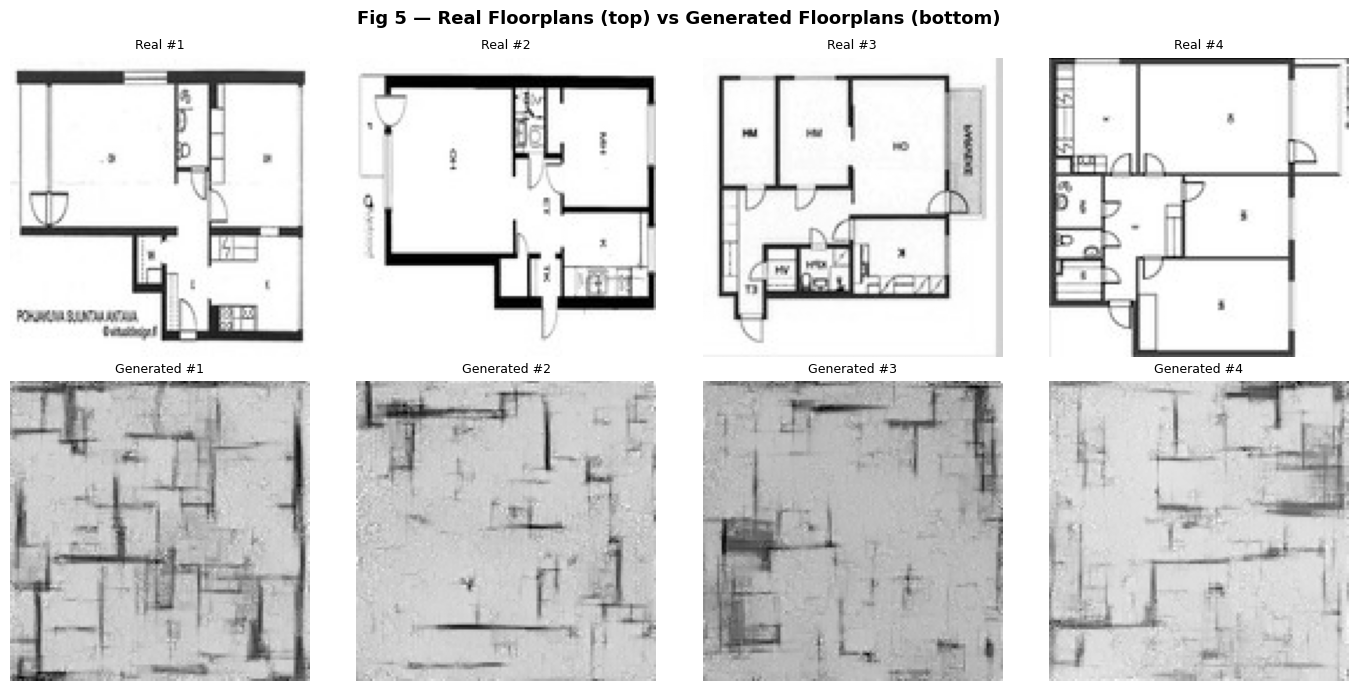

In [19]:
# ── Fig 5: Real vs Generated Side-by-Side ────────────────────────────────────
n_compare = 4
real_samples = [dataset[i][0] for i in range(n_compare)]  # first 4 real images
gen_samples  = flow.sample(loaded_model, n_samples=n_compare,
                            steps=HPARAMS['inference_steps'])

fig, axes = plt.subplots(2, n_compare, figsize=(14, 7))
fig.suptitle('Fig 5 — Real Floorplans (top) vs Generated Floorplans (bottom)',
             fontsize=13, fontweight='bold')

for i in range(n_compare):
    # Real
    real_arr = real_samples[i][0].numpy()
    real_arr = (real_arr - real_arr.min()) / (real_arr.max() - real_arr.min() + 1e-8)
    axes[0, i].imshow(real_arr, cmap='gray')
    axes[0, i].set_title(f'Real #{i+1}', fontsize=9)
    axes[0, i].axis('off')

    # Generated
    gen_arr = gen_samples[i, 0].cpu().numpy()
    gen_arr = (gen_arr - gen_arr.min()) / (gen_arr.max() - gen_arr.min() + 1e-8)
    axes[1, i].imshow(gen_arr, cmap='gray')
    axes[1, i].set_title(f'Generated #{i+1}', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('fig5_real_vs_generated.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 10 — Conclusions

### What We Demonstrated

| Stage | Result |
|---|---|
| Data loading | Custom `FloorplanDataset` with on-the-fly resize + normalisation |
| Architecture | `ConditionalUNet` with sinusoidal time embeddings (~500K params) |
| Training | Flow Matching MSE loss converges smoothly over 30 epochs |
| Generation | Euler ODE solver produces coherent floorplan-like structures |
| Trajectory | Fig 4 shows noise progressively resolving into spatial structure |

### Why Flow Matching Works Well for Spatial Layouts
- **Straight-line paths** in latent space minimise the "work" needed to transport noise to structured images, making the learned velocity field simpler and easier to generalise.
- **No noise schedule design** is required (unlike DDPM), reducing hyperparameter sensitivity.
- The model learns to capture **global structure** (room outlines, corridors) early in training and **fine detail** (wall thickness, door positions) in later epochs.

### Limitations & Extensions
- With more data and a larger model (deeper U-Net, attention layers), output quality improves significantly.
- **Conditional generation** (e.g., generate a floorplan with ≥3 bedrooms) is achievable by expanding `num_classes` and providing multi-class labels.
- **FID score** (Fréchet Inception Distance) would give a quantitative quality metric — requires a pre-trained feature extractor.

In [15]:
print('=' * 55)
print('  TASK 11 — FINAL SUMMARY')
print('=' * 55)
print(f'  Architecture  : ConditionalUNet (Flow Matching)')
print(f'  Dataset       : {len(dataset):,} floorplan images')
print(f'  Image size    : {HPARAMS["img_size"]}×{HPARAMS["img_size"]} grayscale')
print(f'  Epochs        : {HPARAMS["epochs"]}')
print(f'  Final loss    : {loss_history[-1]:.5f}')
print(f'  Model saved   : {MODEL_PATH}')
print(f'  Figures saved : fig1_loss_curve.png')
print(f'                  fig2_generated_floorplans.png')
print(f'                  fig3_single_floorplan.png')
print(f'                  fig4_flow_trajectory.png')
print(f'                  fig5_real_vs_generated.png')
print('=' * 55)

  TASK 11 — FINAL SUMMARY
  Architecture  : ConditionalUNet (Flow Matching)
  Dataset       : 1,000 floorplan images
  Image size    : 128×128 grayscale
  Epochs        : 30
  Final loss    : 0.19112
  Model saved   : floorplan_flow_model.pth
  Figures saved : fig1_loss_curve.png
                  fig2_generated_floorplans.png
                  fig3_single_floorplan.png
                  fig4_flow_trajectory.png
                  fig5_real_vs_generated.png
